# Exploratory Data Analysis

## AI Worker Burnout and Attrition

This notebook explores the cleaned AI worker burnout and attrition dataset.

The analysis focuses on how AI adoption, AI task replacement, job satisfaction, productivity, and burnout are connected.

## Research Questions

1. Is fear of AI replacement associated with burnout?
2. How are AI assistance hours and AI tools related to productivity and burnout?
3. Is there a productivity-burnout tradeoff in AI-supported work?
4. Which AI usage profiles show the most favorable balance between productivity, satisfaction, and burnout?
5. Which variables are most strongly associated with burnout?

# 1. Import Libraries and Load Data

The cleaned dataset from the previous cleaning notebook is loaded for exploratory analysis.

In [1]:
# Import libraries for data analysis and visualization

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# Load the cleaned AI worker burnout dataset

df = pd.read_csv(
    "../data/processed/ai_worker_burnout_cleaned.csv"
)

df.head()

,employee_id,job_role,years_experience,education_level,country,industry,company_size,remote_work_type,team_size,salary_usd_k,...,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,ai_adoption_stage,weekly_ai_upskilling_hrs,productivity_score,burnout_score,job_satisfaction_1_5,fear_of_ai_replacement,attrition_risk
0,EMP0001,Data Analyst,7,PhD,India,Healthtech,Large (1000-5000),Fully Remote,8,184,...,1,0.6,37,Experimenting,4.9,59,58,3.0,Low,Medium
1,EMP0002,DevOps Engineer,3,Self-taught,Canada,Fintech,Large (1000-5000),Hybrid,42,51,...,3,0.6,78,Experimenting,6.6,64,47,3.6,Medium,Medium
2,EMP0003,Prompt Engineer,3,PhD,India,Automotive,Startup (<50),Hybrid,37,185,...,4,4.0,23,Optimizing,5.8,50,37,4.6,High,Medium
3,EMP0004,Backend Engineer,18,Master,Germany,Media,Mid (200-1000),Fully Remote,8,131,...,5,4.2,75,Integrating,1.4,77,67,3.0,Low,Medium
4,EMP0005,AI Researcher,5,Bachelor,India,E-commerce,Small (50-200),Fully Remote,21,99,...,7,0.7,61,Experimenting,1.6,58,54,3.6,Medium,Medium


# 2. Research Question 1

## Is fear of AI replacement associated with burnout?

This section explores whether employees who fear AI replacement show higher burnout scores.

In [2]:
# Calculate average burnout score by fear of AI replacement

df.groupby("fear_of_ai_replacement")["burnout_score"].mean()

fear_of_ai_replacement
High      49.391061
Low       50.397706
Medium    50.155089
Name: burnout_score, dtype: float64

In [3]:
# Calculate average burnout score by attrition risk

df.groupby("attrition_risk")["burnout_score"].mean()

attrition_risk
High      60.80000
Low       44.03453
Medium    55.04631
Name: burnout_score, dtype: float64

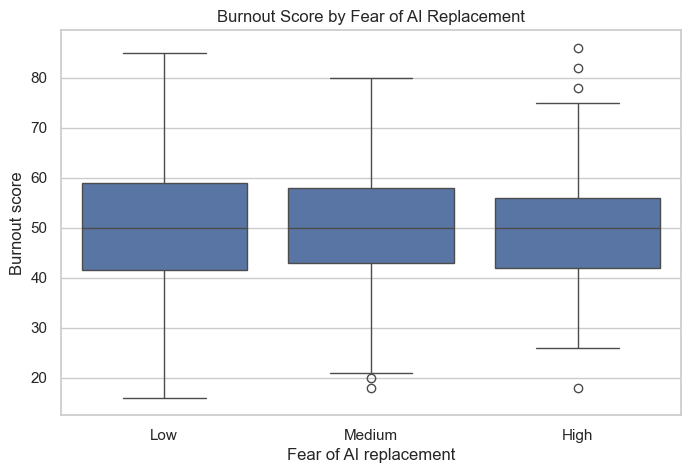

In [4]:
# Visualize burnout score by fear of AI replacement

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="fear_of_ai_replacement",
    y="burnout_score"
)

plt.title("Burnout Score by Fear of AI Replacement")
plt.xlabel("Fear of AI replacement")
plt.ylabel("Burnout score")
plt.show()

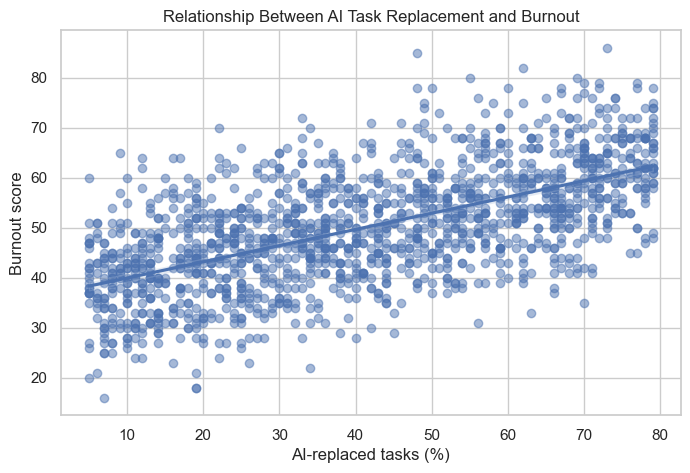

In [5]:
# Visualize relationship between AI task replacement and burnout

plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="ai_replaces_my_tasks_pct",
    y="burnout_score",
    scatter_kws={"alpha": 0.5}
)

plt.title("Relationship Between AI Task Replacement and Burnout")
plt.xlabel("AI-replaced tasks (%)")
plt.ylabel("Burnout score")
plt.show()

### Interpretation

A positive association can be observed between perceived AI task replacement and burnout score.

Employees reporting a higher percentage of AI-replaced tasks tend to show higher burnout scores. However, this is an association only. The dataset does not allow causal conclusions.

# 3. AI Assistance Hours, Productivity and Burnout

This section explores whether daily AI assistance time is associated with productivity and burnout.

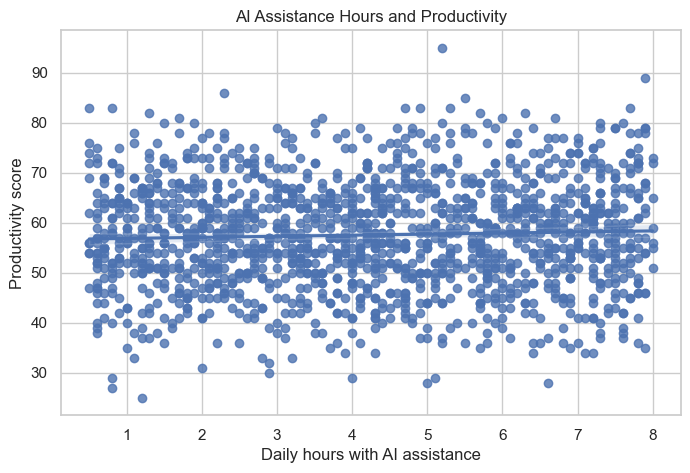

In [6]:
# Visualize relationship between daily AI assistance hours and productivity

plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="hours_with_ai_assistance_daily",
    y="productivity_score"
)

plt.title("AI Assistance Hours and Productivity")
plt.xlabel("Daily hours with AI assistance")
plt.ylabel("Productivity score")
plt.show()

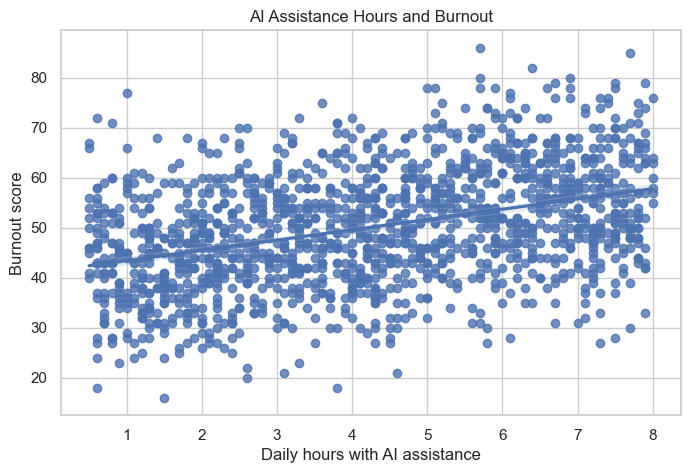

In [7]:
# Visualize relationship between daily AI assistance hours and burnout

plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="hours_with_ai_assistance_daily",
    y="burnout_score"
)

plt.title("AI Assistance Hours and Burnout")
plt.xlabel("Daily hours with AI assistance")
plt.ylabel("Burnout score")
plt.show()

In [8]:
# Compare burnout score across AI adoption stages

df.groupby(
    "ai_adoption_stage"
)["burnout_score"].mean()

ai_adoption_stage
AI-First         50.492000
Experimenting    49.667598
Integrating      50.166667
Optimizing       50.000000
Name: burnout_score, dtype: float64

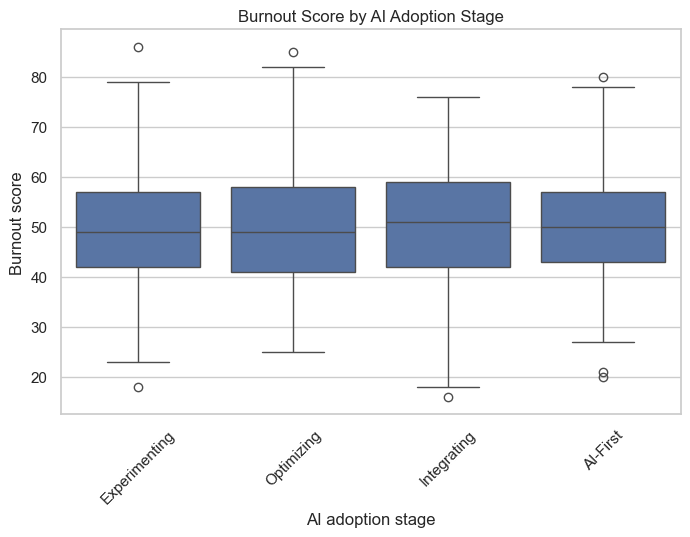

In [9]:
# Visualize burnout score by AI adoption stage

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="ai_adoption_stage",
    y="burnout_score"
)

plt.title("Burnout Score by AI Adoption Stage")
plt.xlabel("AI adoption stage")
plt.ylabel("Burnout score")
plt.xticks(rotation=45)
plt.show()

### Interpretation

AI assistance hours and AI adoption stage provide an early view of how deeply AI is integrated into employees' daily work.

The visual patterns should be interpreted together with later correlation and grouped analyses because individual scatterplots can be noisy.

# 4. Burnout Across Employee Groups

This section compares burnout scores across education levels, attrition risk groups, job roles, industries, and remote work types.

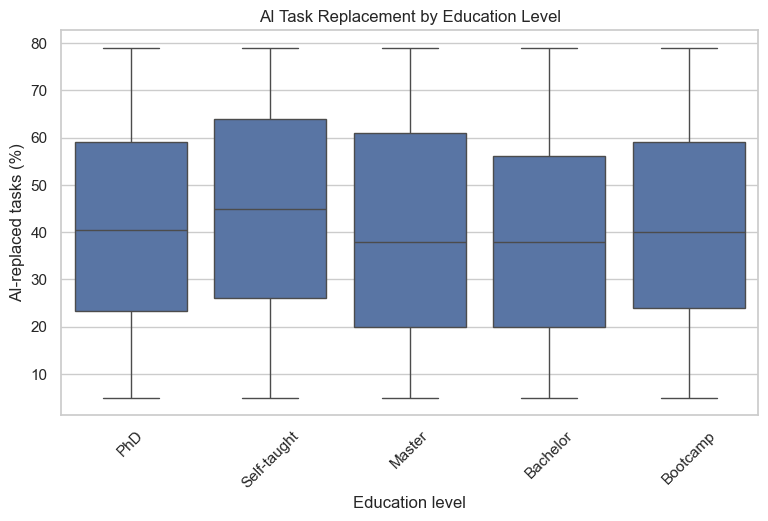

In [10]:
# Compare perceived AI task replacement across education levels

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="education_level",
    y="ai_replaces_my_tasks_pct"
)

plt.title("AI Task Replacement by Education Level")
plt.xlabel("Education level")
plt.ylabel("AI-replaced tasks (%)")
plt.xticks(rotation=45)
plt.show()

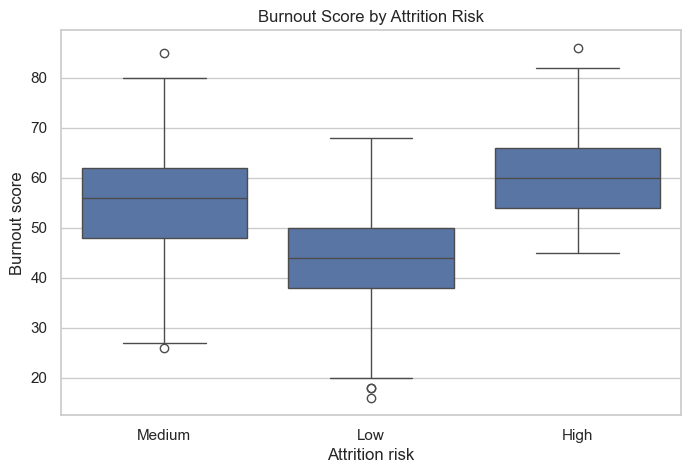

In [11]:
# Visualize burnout score by attrition risk

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="attrition_risk",
    y="burnout_score"
)

plt.title("Burnout Score by Attrition Risk")
plt.xlabel("Attrition risk")
plt.ylabel("Burnout score")
plt.show()

In [12]:
# Calculate average burnout score by job role

df.groupby("job_role")["burnout_score"].mean().sort_values()

job_role
Prompt Engineer      47.657143
AI Researcher        48.748148
Product Manager      49.121951
Frontend Engineer    49.310345
AI Ethics Officer    49.712121
Cloud Architect      50.376923
Data Scientist       50.548148
ML Engineer          50.697248
Backend Engineer     50.921260
Data Analyst         50.926230
DevOps Engineer      50.931034
Software Engineer    51.266667
Name: burnout_score, dtype: float64

In [13]:
# Calculate average burnout score by industry

df.groupby("industry")["burnout_score"].mean().sort_values()

industry
Automotive       48.720779
Cybersecurity    49.765625
Consulting       49.792208
Fintech          49.833333
Media            49.918367
Healthtech       50.073826
EdTech           50.123529
E-commerce       50.529032
Gaming           50.532164
SaaS             51.305970
Name: burnout_score, dtype: float64

In [14]:
# Calculate average burnout score by remote work type

df.groupby("remote_work_type")["burnout_score"].mean()

remote_work_type
Fully Remote    50.217993
Hybrid          49.627713
On-site         50.566563
Name: burnout_score, dtype: float64

### Group comparison interpretation

Burnout can differ across job roles, industries, remote work types, and attrition risk groups.

These group-level comparisons are useful for identifying where burnout may be higher, but they should not be interpreted as causal effects.

# 5. Research Question 2

## How are AI assistance hours related to productivity, burnout and job satisfaction?

This section groups daily AI assistance hours and compares average productivity, burnout, and job satisfaction.

In [15]:
# Compare burnout score across daily AI assistance hour groups

df.groupby(
    pd.cut(
        df["hours_with_ai_assistance_daily"],
        bins=[0, 2, 4, 6, 8]
    )
)["burnout_score"].mean()

hours_with_ai_assistance_daily
(0, 2]    43.729642
(2, 4]    47.721805
(4, 6]    51.890511
(6, 8]    55.595300
Name: burnout_score, dtype: float64

In [16]:
# Calculate correlations between AI assistance hours, burnout, and productivity

corr = df[
    ["hours_with_ai_assistance_daily",
     "burnout_score",
     "productivity_score"]
].corr()

corr

,hours_with_ai_assistance_daily,burnout_score,productivity_score
hours_with_ai_assistance_daily,1.000000,0.385597,0.043123
burnout_score,0.385597,1.000000,-0.005322
productivity_score,0.043123,-0.005322,1.000000


In [17]:
# Compare productivity and job satisfaction across daily AI assistance hour groups

df.groupby(
    pd.cut(
        df["hours_with_ai_assistance_daily"],
        bins=[0, 2, 4, 6, 8]
    )
)[
    ["productivity_score",
     "job_satisfaction_1_5"]
].mean()

,productivity_score,job_satisfaction_1_5
hours_with_ai_assistance_daily,,
"(0, 2]",57.254072,3.580456
"(2, 4]",56.889724,3.412782
"(4, 6]",57.574209,3.262287
"(6, 8]",58.422977,3.134204


In [18]:
# Create daily AI assistance hour groups

df["hours_group"] = pd.cut(
    df["hours_with_ai_assistance_daily"],
    bins=[0, 2, 4, 6, 8],
    labels=["0-2h", "2-4h", "4-6h", "6-8h"]
)

# Calculate average productivity, burnout and satisfaction by hour group

summary_hours = df.groupby("hours_group", observed=False)[
    [
        "productivity_score",
        "burnout_score",
        "job_satisfaction_1_5"
    ]
].mean()

summary_hours

,productivity_score,burnout_score,job_satisfaction_1_5
hours_group,,,
0-2h,57.254072,43.729642,3.580456
2-4h,56.889724,47.721805,3.412782
4-6h,57.574209,51.890511,3.262287
6-8h,58.422977,55.595300,3.134204


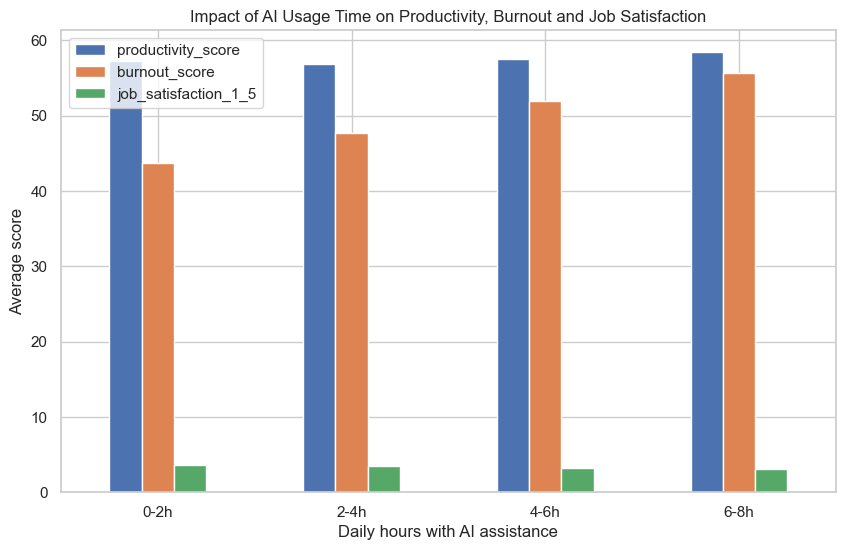

In [19]:
# Visualize productivity, burnout and job satisfaction by AI assistance time

summary_hours.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Impact of AI Usage Time on Productivity, Burnout and Job Satisfaction")
plt.xlabel("Daily hours with AI assistance")
plt.ylabel("Average score")
plt.xticks(rotation=0)
plt.show()

### Interpretation

Grouping AI assistance hours makes it easier to compare average outcomes.

This analysis helps evaluate whether more AI-supported work is associated with productivity benefits, higher burnout, or changes in job satisfaction.

# 6. Research Question 3

## Is there a productivity-burnout tradeoff?

Productivity, burnout and job satisfaction are measured on different scales.

To compare their trends visually, the values are normalized to a 0–1 range.

In [20]:
# Normalize productivity, burnout and satisfaction to compare trends

summary_scaled = (
    summary_hours - summary_hours.min()
) / (
    summary_hours.max() - summary_hours.min()
)

summary_scaled = summary_scaled.rename(
    columns={
        "productivity_score": "Productivity",
        "burnout_score": "Burnout risk",
        "job_satisfaction_1_5": "Job satisfaction"
    }
)

summary_scaled

,Productivity,Burnout risk,Job satisfaction
hours_group,,,
0-2h,0.237630,0.000000,1.000000
2-4h,0.000000,0.336447,0.624262
4-6h,0.446427,0.687772,0.287020
6-8h,1.000000,1.000000,0.000000


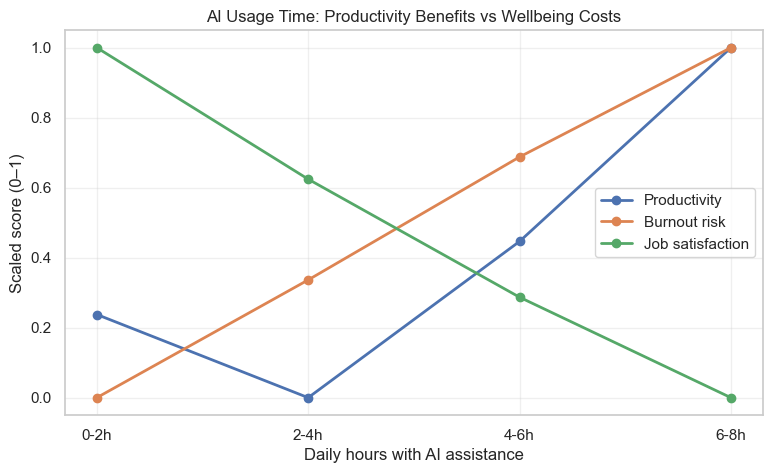

In [21]:
# Plot normalized trends across AI assistance hour groups

plt.figure(figsize=(9, 5))

for col in summary_scaled.columns:
    plt.plot(
        summary_scaled.index,
        summary_scaled[col],
        marker="o",
        linewidth=2,
        label=col
    )

plt.title("AI Usage Time: Productivity Benefits vs Wellbeing Costs")
plt.xlabel("Daily hours with AI assistance")
plt.ylabel("Scaled score (0–1)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

### Normalized trend interpretation

The normalized plot compares the direction of change across variables with different original scales.

It should be used to compare trends, not absolute values. A higher normalized burnout line means higher relative burnout risk within the observed hour groups.

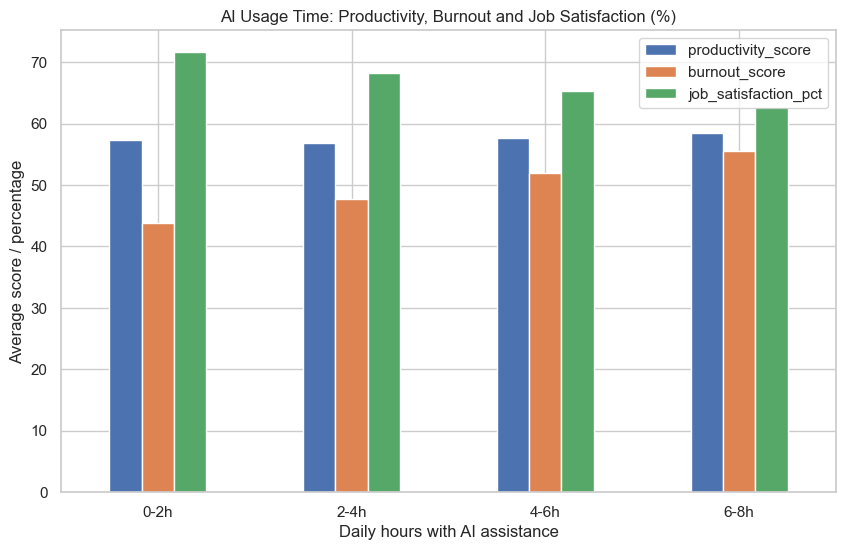

In [22]:
# Convert job satisfaction from a 1-5 scale to percentage for direct visual comparison

summary_hours_display = summary_hours.copy()

summary_hours_display["job_satisfaction_pct"] = (
    summary_hours_display["job_satisfaction_1_5"] / 5 * 100
)

summary_hours_display[
    [
        "productivity_score",
        "burnout_score",
        "job_satisfaction_pct"
    ]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("AI Usage Time: Productivity, Burnout and Job Satisfaction (%)")
plt.xlabel("Daily hours with AI assistance")
plt.ylabel("Average score / percentage")
plt.xticks(rotation=0)
plt.show()

### Scale adjustment note

Productivity and burnout are already measured on a 0–100 scale. Job satisfaction was converted from a 1–5 scale into a percentage of the maximum possible score to allow a clearer visual comparison.

# 7. AI Tools Used Per Day

This section examines whether using more AI tools per day is associated with productivity, burnout, and job satisfaction.

In [23]:
# Calculate average productivity by number of AI tools used per day

df.groupby("ai_tools_used_per_day")[
    "productivity_score"
].mean()

ai_tools_used_per_day
1    52.782178
2    53.545000
3    54.876777
4    58.213043
5    59.964758
6    60.657407
7    61.971963
Name: productivity_score, dtype: float64

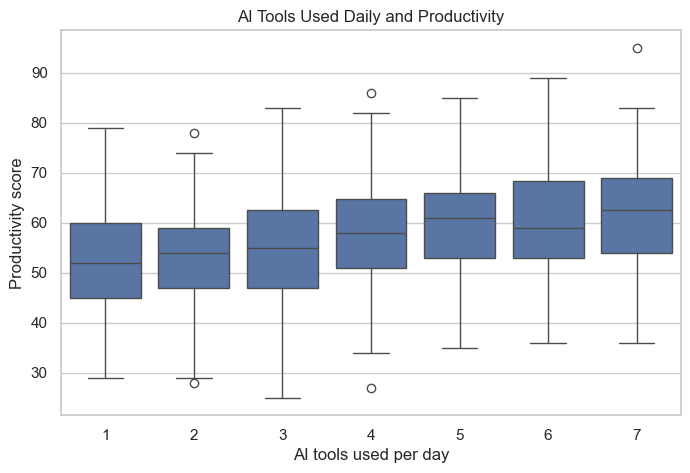

In [24]:
# Visualize productivity by number of AI tools used per day

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="ai_tools_used_per_day",
    y="productivity_score"
)

plt.title("AI Tools Used Daily and Productivity")
plt.xlabel("AI tools used per day")
plt.ylabel("Productivity score")
plt.show()

In [25]:
# Compare productivity, burnout and job satisfaction by number of AI tools

summary_tools = df.groupby(
    "ai_tools_used_per_day"
)[
    [
        "productivity_score",
        "burnout_score",
        "job_satisfaction_1_5"
    ]
].mean()

summary_tools

,productivity_score,burnout_score,job_satisfaction_1_5
ai_tools_used_per_day,,,
1,52.782178,49.886139,3.308416
2,53.545000,50.900000,3.251500
3,54.876777,50.488152,3.310427
4,58.213043,49.152174,3.340435
5,59.964758,49.136564,3.393392
6,60.657407,50.782407,3.364352
7,61.971963,50.224299,3.363084


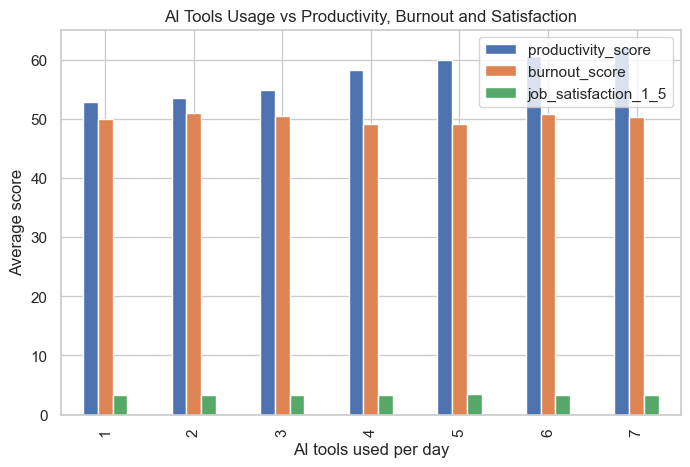

In [26]:
# Visualize average productivity, burnout and satisfaction by number of AI tools

summary_tools.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("AI Tools Usage vs Productivity, Burnout and Satisfaction")
plt.xlabel("AI tools used per day")
plt.ylabel("Average score")
plt.show()

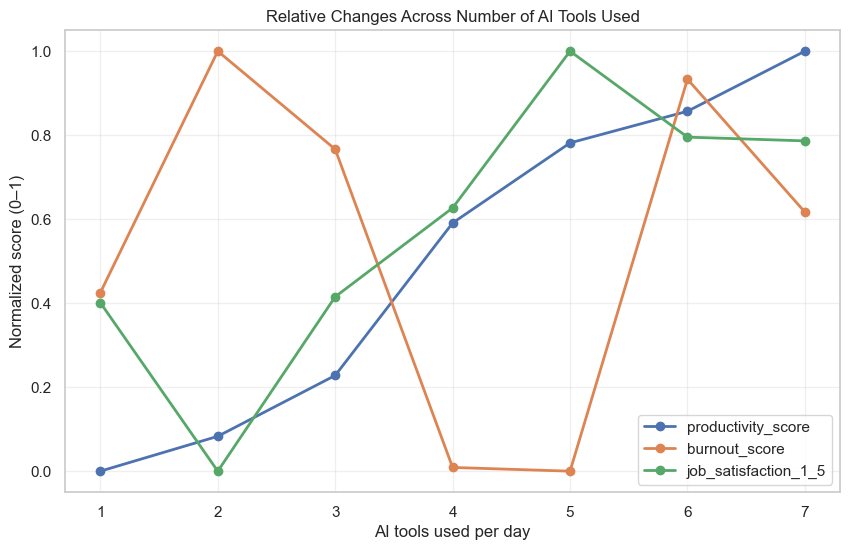

In [27]:
# Normalize tool-based outcome trends to compare relative changes

summary_tools_scaled = (
    summary_tools - summary_tools.min()
) / (
    summary_tools.max() - summary_tools.min()
)

plt.figure(figsize=(10, 6))

for col in summary_tools_scaled.columns:
    plt.plot(
        summary_tools_scaled.index,
        summary_tools_scaled[col],
        marker="o",
        linewidth=2,
        label=col
    )

plt.title("Relative Changes Across Number of AI Tools Used")
plt.xlabel("AI tools used per day")
plt.ylabel("Normalized score (0–1)")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

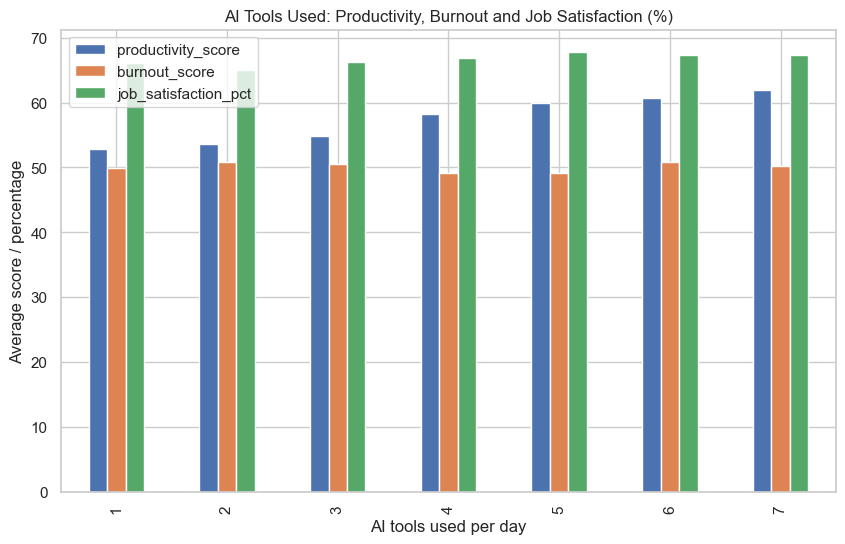

In [28]:
# Convert job satisfaction to percentage for direct comparison with 0-100 scores

summary_tools_display = summary_tools.copy()

summary_tools_display["job_satisfaction_pct"] = (
    summary_tools_display["job_satisfaction_1_5"] / 5 * 100
)

summary_tools_display[
    [
        "productivity_score",
        "burnout_score",
        "job_satisfaction_pct"
    ]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("AI Tools Used: Productivity, Burnout and Job Satisfaction (%)")
plt.xlabel("AI tools used per day")
plt.ylabel("Average score / percentage")
plt.show()

### AI tools interpretation

The number of AI tools used per day provides another perspective on AI engagement.

The analysis compares whether higher tool usage is associated with higher productivity, higher burnout, or changes in job satisfaction.

# 8. Correlation Matrix

This section summarizes numerical relationships between productivity, burnout, satisfaction, AI usage intensity, and AI task replacement.

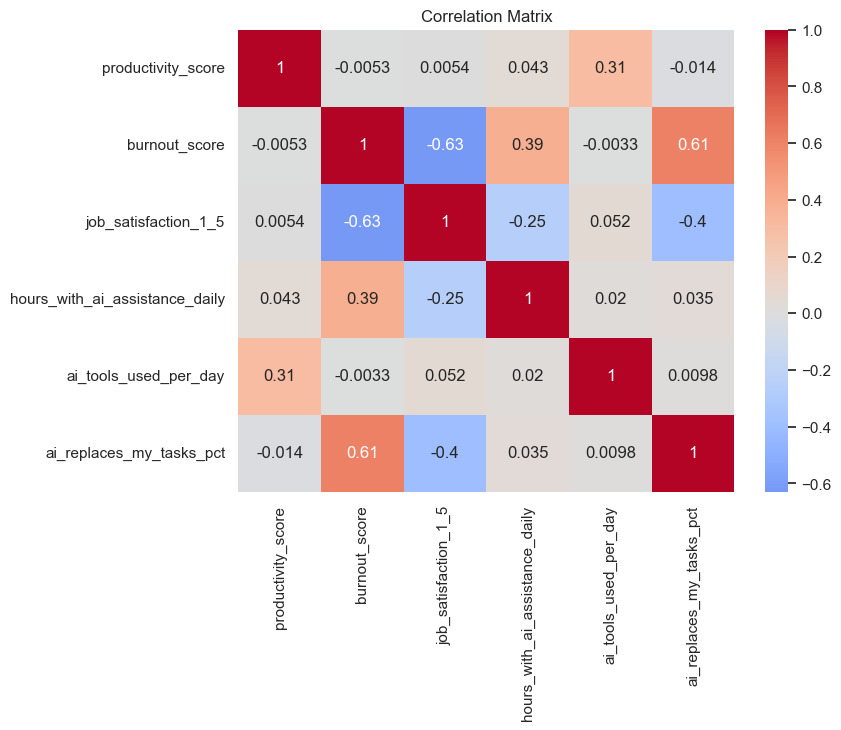

In [29]:
# Calculate and visualize correlations between key numerical variables

corr = df[
    [
        "productivity_score",
        "burnout_score",
        "job_satisfaction_1_5",
        "hours_with_ai_assistance_daily",
        "ai_tools_used_per_day",
        "ai_replaces_my_tasks_pct"
    ]
].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

### Correlation interpretation

The correlation matrix helps identify which variables are most closely related to burnout and productivity.

It is especially useful for deciding which features may be relevant for later modeling.

# 9. Research Question 4

## Which AI usage profiles show the best balance between productivity and wellbeing?

This section creates grouped AI usage profiles based on:

- daily AI assistance hours,
- number of AI tools used per day.

The goal is to compare productivity, burnout, and satisfaction across different AI usage profiles.

In [30]:
# Create grouped AI usage variables

df["hours_group"] = pd.cut(
    df["hours_with_ai_assistance_daily"],
    bins=[0, 2, 5, 8],
    labels=["Low hours", "Medium hours", "High hours"],
    include_lowest=True
)

df["tools_group"] = pd.cut(
    df["ai_tools_used_per_day"],
    bins=[0, 2, 5, 7],
    labels=["Few tools", "Moderate tools", "Many tools"],
    include_lowest=True
)

# Calculate mean outcomes for each AI usage profile

profile_summary = (
    df.groupby(["hours_group", "tools_group"], observed=False)[
        [
            "productivity_score",
            "burnout_score",
            "job_satisfaction_1_5"
        ]
    ]
    .mean()
    .round(2)
)

profile_summary

productivity_score  burnout_score  \
hours_group  tools_group                                         
Low hours    Few tools                    51.69          45.55   
             Moderate tools               58.04          42.38   
             Many tools                   61.31          44.04   
Medium hours Few tools                    53.87          48.58   
             Moderate tools               56.94          47.95   
             Many tools                   60.37          48.70   
High hours   Few tools                    53.21          54.92   
             Moderate tools               58.51          55.18   
             Many tools                   62.29          55.83   

                             job_satisfaction_1_5  
hours_group  tools_group                           
Low hours    Few tools                       3.46  
             Moderate tools                  3.63  
             Many tools                      3.62  
Medium hours Few tools                       3.36  
             Moderate tools                  3.38  
             Many tools                      3.41  
High hours   Few tools                       3.10  
             Moderate tools                  3.17  
             Many tools                      3.18

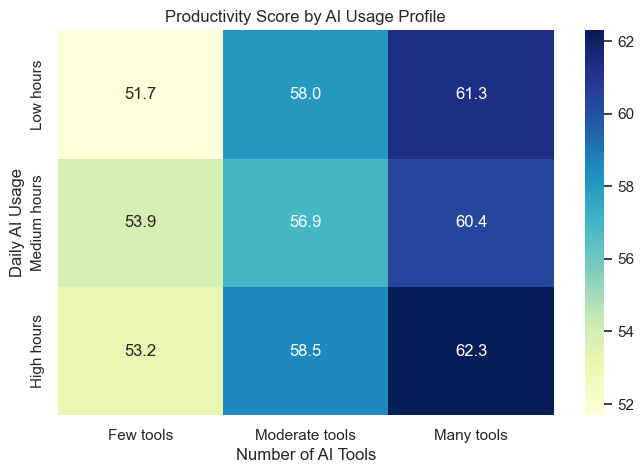

In [31]:
# Create heatmap of productivity score by AI usage profile

productivity_pivot = df.pivot_table(
    values="productivity_score",
    index="hours_group",
    columns="tools_group",
    aggfunc="mean",
    observed=False
)

plt.figure(figsize=(8, 5))

sns.heatmap(
    productivity_pivot,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("Productivity Score by AI Usage Profile")
plt.xlabel("Number of AI Tools")
plt.ylabel("Daily AI Usage")

plt.show()

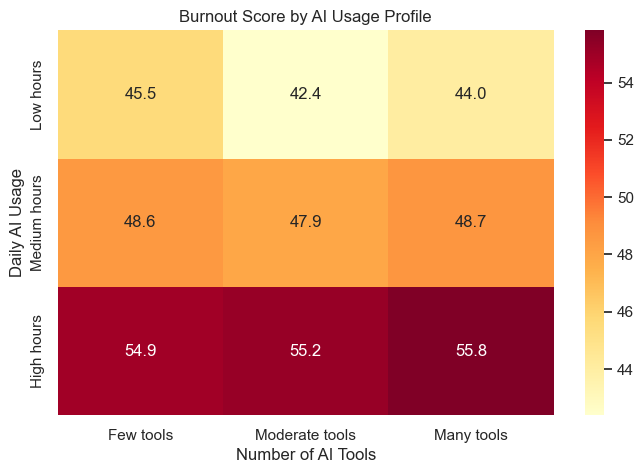

In [32]:
# Create heatmap of burnout score by AI usage profile

burnout_pivot = df.pivot_table(
    values="burnout_score",
    index="hours_group",
    columns="tools_group",
    aggfunc="mean",
    observed=False
)

plt.figure(figsize=(8, 5))

sns.heatmap(
    burnout_pivot,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd"
)

plt.title("Burnout Score by AI Usage Profile")
plt.xlabel("Number of AI Tools")
plt.ylabel("Daily AI Usage")

plt.show()

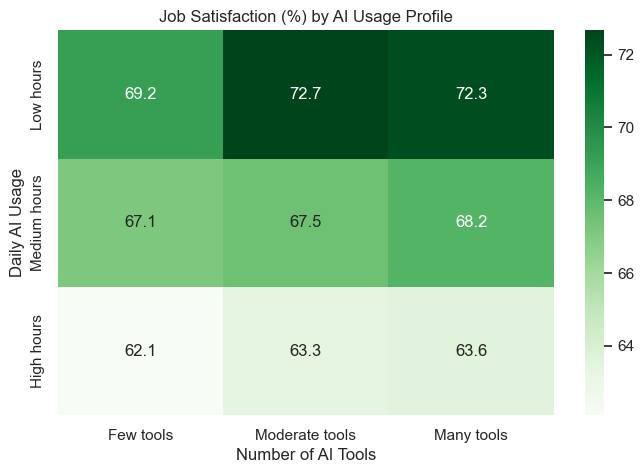

In [33]:
# Convert job satisfaction from 1-5 scale to percentage

df["job_satisfaction_pct"] = (
    df["job_satisfaction_1_5"] / 5 * 100
)

# Create heatmap of job satisfaction by AI usage profile

satisfaction_pivot = df.pivot_table(
    values="job_satisfaction_pct",
    index="hours_group",
    columns="tools_group",
    aggfunc="mean",
    observed=False
)

plt.figure(figsize=(8, 5))

sns.heatmap(
    satisfaction_pivot,
    annot=True,
    fmt=".1f",
    cmap="Greens"
)

plt.title("Job Satisfaction (%) by AI Usage Profile")
plt.xlabel("Number of AI Tools")
plt.ylabel("Daily AI Usage")

plt.show()

### AI usage profile interpretation

The heatmaps compare AI usage profiles across productivity, burnout, and satisfaction.

This format is useful because it shows that AI intensity is not one-dimensional: both time spent with AI and number of tools used can matter.

# 10. AI Benefit Index

To evaluate the balance between productivity benefits and wellbeing costs, an AI Benefit Index is created.

The index combines:

- productivity score,
- job satisfaction converted to a 0–100 scale,
- burnout score as a negative component.

Formula:

`AI Benefit Index = Productivity Score + Job Satisfaction (%) - Burnout Score`

Higher values indicate a more favorable balance between productivity, satisfaction, and burnout.

In [34]:
# Create an AI benefit index
# Higher productivity and satisfaction increase the score,
# higher burnout decreases it.

df["ai_benefit_index"] = (
    df["productivity_score"]
    + df["job_satisfaction_pct"]
    - df["burnout_score"]
)

# Compare benefit index across AI usage profiles

benefit_summary = (
    df.groupby(["hours_group", "tools_group"], observed=False)[
        "ai_benefit_index"
    ]
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

benefit_summary

hours_group   tools_group   
Low hours     Many tools        89.58
              Moderate tools    88.34
Medium hours  Many tools        79.91
              Moderate tools    76.54
Low hours     Few tools         75.31
Medium hours  Few tools         72.40
High hours    Many tools        70.05
              Moderate tools    66.66
              Few tools         60.38
Name: ai_benefit_index, dtype: float64

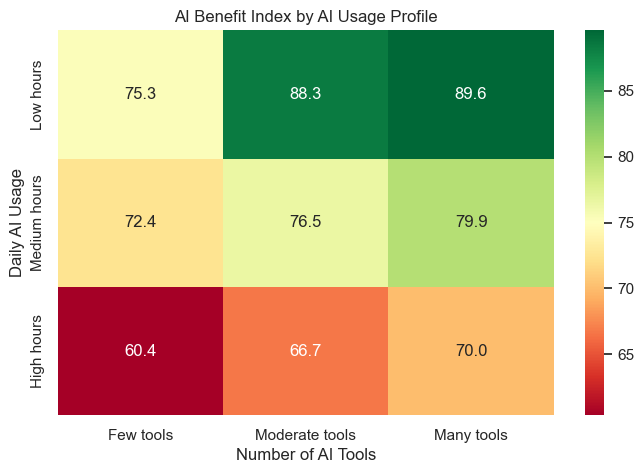

In [35]:
# Visualize AI benefit index by AI usage profile

benefit_pivot = df.pivot_table(
    values="ai_benefit_index",
    index="hours_group",
    columns="tools_group",
    aggfunc="mean",
    observed=False
)

plt.figure(figsize=(8, 5))

sns.heatmap(
    benefit_pivot,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn"
)

plt.title("AI Benefit Index by AI Usage Profile")
plt.xlabel("Number of AI Tools")
plt.ylabel("Daily AI Usage")

plt.show()

### AI Benefit Index interpretation

The AI Benefit Index is a simplified analytical measure. It helps compare AI usage profiles by balancing productivity and satisfaction against burnout.

The index should not be interpreted as an official psychological or business metric. It is used here as an exploratory tool to summarize competing outcomes.

# 11. Research Question 5

## Which variables are most strongly associated with burnout?

This section ranks numerical correlations with burnout score.

In [36]:
# Calculate correlations with burnout score

corr_burnout = (
    df.select_dtypes(include=["number"])
      .corr()["burnout_score"]
      .sort_values(ascending=False)
)

corr_burnout

burnout_score                     1.000000
ai_replaces_my_tasks_pct          0.613375
hours_with_ai_assistance_daily    0.385597
team_size                         0.017171
salary_usd_k                      0.013118
years_experience                  0.004534
ai_tools_used_per_day            -0.003333
productivity_score               -0.005322
weekly_ai_upskilling_hrs         -0.014869
job_satisfaction_1_5             -0.629328
job_satisfaction_pct             -0.629328
ai_benefit_index                 -0.800358
Name: burnout_score, dtype: float64

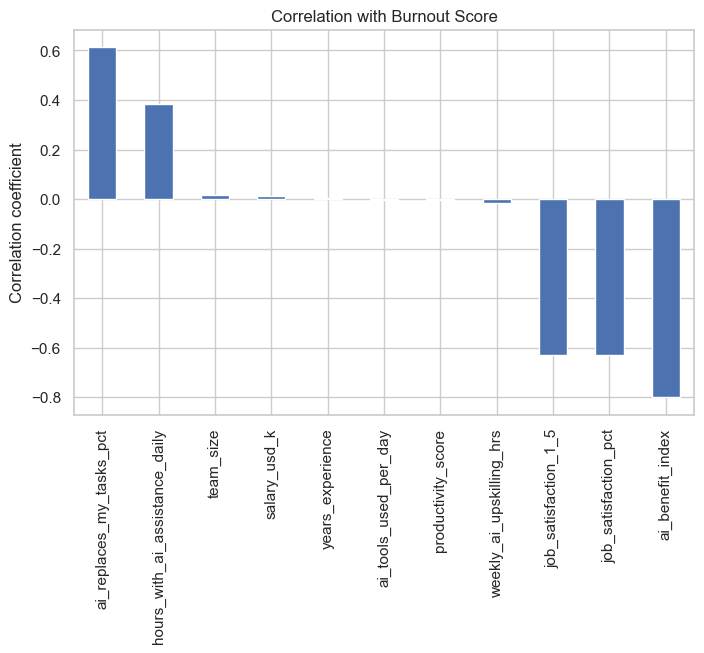

In [37]:
# Visualize correlations with burnout score

plt.figure(figsize=(8, 5))

corr_burnout.drop("burnout_score").plot(
    kind="bar"
)

plt.title("Correlation with Burnout Score")
plt.ylabel("Correlation coefficient")
plt.show()

### Burnout correlation interpretation

The correlation ranking helps identify which numerical variables are most closely associated with burnout score.

This is useful for the next modeling notebook, where burnout or attrition risk can be predicted using selected features.

# 12. Limitations

Several limitations should be considered:

- The analysis is observational and does not prove causality.
- Some variables are self-reported and may contain perception bias.
- Group averages can hide individual-level variation.
- The AI Benefit Index is an exploratory metric created for this project and should not be treated as a validated measure.
- Further statistical testing or modeling is needed to confirm which variables are most useful for prediction.

# 13. Conclusion

This EDA explored how AI usage relates to productivity, burnout, job satisfaction, and attrition-related indicators.

Key findings:

- Higher perceived AI task replacement is associated with higher burnout scores.
- Burnout appears closely connected to attrition risk.
- AI assistance hours and number of tools can be used to describe different AI usage profiles.
- Productivity, burnout, and job satisfaction need to be interpreted together because productivity gains may come with wellbeing costs.
- The AI Benefit Index provides a simple way to compare AI usage profiles.
- Correlation analysis identifies variables that may be useful for modeling.

The next step is to use these insights to build predictive models and evaluate whether burnout or attrition risk can be predicted from the available features.